In [18]:
import numpy as np, json, os, sys, pandas as pd
import random
sys.path.append("../")
from bound_analysis.new_bound_core import compute_new_error_bound
from bound_analysis.old_bound_core import compute_old_error_bound
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# load results and pairwise metrics
all_algos = ["simclr", "ijepa", "mae", "clip", "dinov2", "siglip", "vicreg"]
cur_algo = all_algos[2]
nccc_dir = f"../results/{cur_algo}/accuracy"
nccc_df = pd.read_csv(os.path.join(nccc_dir, "nccc.csv"))

import ast
def get_average_nccc(df):
    df["train_acc"] = df["train_acc"].apply(lambda x: float(ast.literal_eval(x)[0]))
    df["test_acc"]  = df["test_acc"].apply(lambda x: float(ast.literal_eval(x)[0]))
    # Group by n_shot and compute mean ± std across seeds
    summary = df.groupby("n_shot").agg(
        train_mean=("train_acc", "mean"),
        train_std=("train_acc", "std"),
        test_mean=("test_acc", "mean"),
        test_std=("test_acc", "std"),
    ).reset_index().sort_values("n_shot")
    return summary

nccc_df = get_average_nccc(nccc_df)
nccc_df.head()

,n_shot,train_mean,train_std,test_mean,test_std
0,1,0.858474,0.048566,0.853333,0.093524
1,5,0.959756,0.028607,0.958333,0.057764
2,10,0.962551,0.029232,0.955000,0.056480
3,20,0.964000,0.025661,0.946000,0.037815
4,50,0.967200,0.022884,0.946000,0.035071


### Old bound

In [20]:
geom_dir = f"../results/{cur_algo}/geometry"
cdnv_file = os.path.join(geom_dir, "cdnv.csv")
cdnv_df = pd.read_csv(cdnv_file)
cdnv = cdnv_df["CDNV"].values[0]
test_cdnv = cdnv_df["Test_CDNV"].values[0]
print(f"CDNV: {cdnv}")
print(f"Test CDNV: {test_cdnv}")
dir_cdnv = cdnv_df["Directional_CDNV"].values[0]
test_dir_cdnv = cdnv_df["Test_Directional_CDNV"].values[0]
print(f"Directional CDNV: {dir_cdnv}")
print(f"Test Directional CDNV: {test_dir_cdnv}")

CDNV: 1.672136664390564
Test CDNV: 1.4867945909500122
Directional CDNV: 0.0728605240583419
Test Directional CDNV: 0.0640006586909294


In [21]:
from collections import defaultdict
old_train_error_bounds = defaultdict()
old_test_error_bounds = defaultdict()
for m in nccc_df["n_shot"].values:
    err_bound = compute_old_error_bound(dir_cdnv, cdnv, m)
    old_train_error_bounds[int(m)] = float(err_bound)
    err_bound = compute_old_error_bound(test_dir_cdnv, test_cdnv, m)
    old_test_error_bounds[int(m)] = float(err_bound)

print("Old Train Error Bounds:", old_train_error_bounds)
print("Old Test Error Bounds:", old_test_error_bounds)

Old Train Error Bounds: defaultdict(None, {1: 29.11435549029107, 5: 8.196054138038143, 10: 5.666351924150673, 20: 4.166720807387859, 50: 2.945370195656947, 100: 2.3345435296937462, 200: 1.8863966812315267, 500: 1.4591703614033298})
Old Test Error Bounds: defaultdict(None, {1: 26.2929384829605, 5: 7.39594411532652, 10: 5.109498998830397, 20: 3.753975941201195, 50: 2.6500457996727405, 100: 2.0980612176271896, 200: 1.693213272120536, 500: 1.3074534079278886})


### New bound

In [22]:
geom_dir = f"../results/{cur_algo}/geometry"
train_metrics_file = os.path.join(geom_dir, "train_pairwise_metrics.json")
test_metrics_file = os.path.join(geom_dir, "test_pairwise_metrics.json")

def load_pairwise_metrics(metrics_file):
    # convert "i_j" keys to (i,j) tuple keys
    with open(metrics_file, "r") as f:
        raw_metrics = json.load(f)
    pairwise_metrics = {}
    for key, val in raw_metrics.items():
        i, j = map(int, key.split("_"))
        pairwise_metrics[(i,j)] = val
    return pairwise_metrics

train_pairwise_metrics = load_pairwise_metrics(train_metrics_file)
test_pairwise_metrics  = load_pairwise_metrics(test_metrics_file)

In [23]:
from collections import defaultdict
SEEDS = np.arange(5)
train_error_bounds = defaultdict(list)
test_error_bounds = defaultdict(list)

avg_d_cdnv = 0.0
for seed in SEEDS:
    random.seed(int(seed))
    classes_groups = random.sample(range(100), 2)
    for m in nccc_df["n_shot"].values:
        m = int(m)  # make sure it's a plain int
        m_err_train = float(compute_new_error_bound(train_pairwise_metrics, m, sel_classes=classes_groups))
        m_err_test  = float(compute_new_error_bound(test_pairwise_metrics, m, sel_classes=classes_groups))
        train_error_bounds[m].append(m_err_train)
        test_error_bounds[m].append(m_err_test)
    
    # append m=1e+6 error bounds
    inf_err_train = float(compute_new_error_bound(train_pairwise_metrics, int(1e+6), sel_classes=classes_groups))
    inf_err_test  = float(compute_new_error_bound(test_pairwise_metrics, int(1e+6), sel_classes=classes_groups))
    train_error_bounds[int(1e+6)].append(inf_err_train)
    test_error_bounds[int(1e+6)].append(inf_err_test)
    
    i = classes_groups[0]
    j = classes_groups[1]
    vals = train_pairwise_metrics.get((i, j), None)
    Vtilde = vals['Vtilde_ij']
    avg_d_cdnv += Vtilde
    vals = train_pairwise_metrics.get((j, i), None)
    Vtilde = vals['Vtilde_ij']
    avg_d_cdnv += Vtilde

# average across seeds, convert to normal numbers
final_train_bounds = {int(m): float(np.mean(train_error_bounds[m])) for m in train_error_bounds}
final_test_bounds  = {int(m): float(np.mean(test_error_bounds[m]))  for m in test_error_bounds}

print(final_train_bounds)
print(final_test_bounds)

avg_d_cdnv /= (2 * len(SEEDS))
print(f"Average d_cdnv over selected pairs and seeds: {avg_d_cdnv}")

{1: 57.4367741256101, 5: 9.466141113503722, 10: 4.416784401986439, 20: 2.1639204072012435, 50: 0.9431722743510076, 100: 0.5684017542288922, 200: 0.3899509070281977, 500: 0.28696647550394383, 1000000: 0.22116436556733038}
{1: 70.05853245259576, 5: 10.495339738810959, 10: 4.87768109235293, 20: 2.386296678887739, 50: 1.0398186529066489, 100: 0.6270690164022609, 200: 0.4306904300117809, 500: 0.3174304610915438, 1000000: 0.24511164656145307}
Average d_cdnv over selected pairs and seeds: 0.05528321322053671


### Plots

In [24]:
train_error =  1 - nccc_df["train_mean"].values
test_error  =  1 - nccc_df["test_mean"].values
m_values    =  nccc_df["n_shot"].values

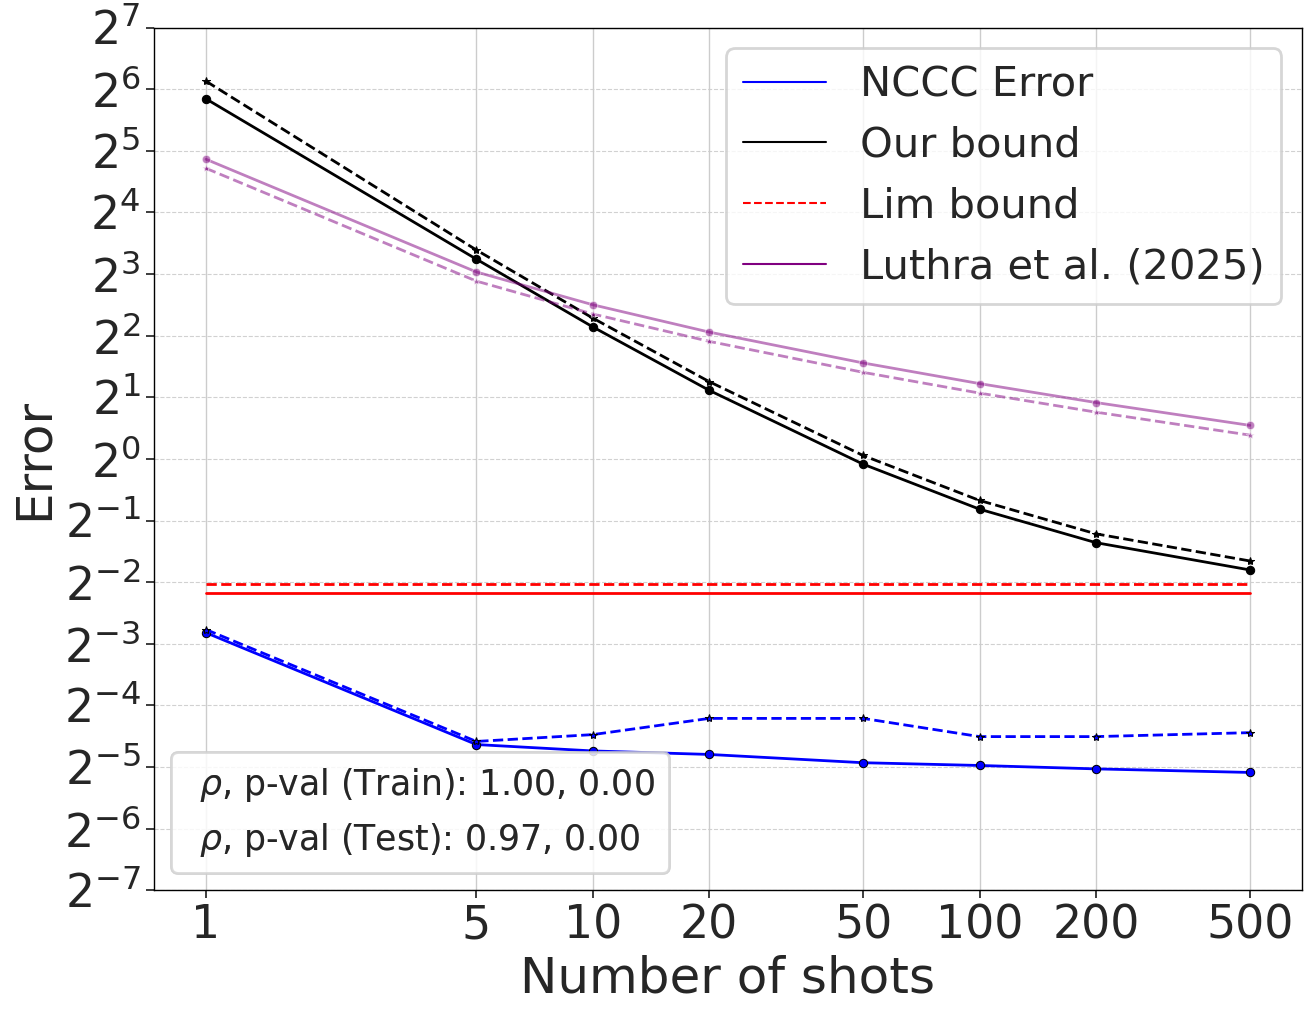

In [ ]:
from bound_analysis.bound_viz import plot_error_bound

plot_error_bound(train_error=train_error,
                 test_error=test_error,
                 m_values=m_values,
                 train_error_bound=final_train_bounds,
                 test_error_bound=final_test_bounds,
                 old_train_error_bound=old_train_error_bounds,
                 old_test_error_bound=old_test_error_bounds,
                 output_path=f"../results/{cur_algo}/error_bounds.png")